# NB1: Ground Truth Comparison
- **Question:** How does the choice of ground truth (Original vs Platinum) change performance evaluation?
- **Primary GT:** Platinum Consensus
- **KL1 Strategy:** Evaluates all three strategies (Exclude, Clinical, Sensitivity 1) to demonstrate robustness.
- **Hypothesis:** Artificial label noise in the original repository structurally penalizes correct human and AI decisions, resulting in a false "accuracy paradox" where better real-world performance looks worse on paper.
- **Data Note:** This notebook uses the finalized **N=51 completer cohort**. All non-completers are excluded.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, f1_score
from statsmodels.stats.contingency_tables import mcnemar
import warnings
import sys, os; sys.path.append(os.path.abspath(".")); sys.path.append(os.path.abspath("..")); import helpers

warnings.filterwarnings("ignore")

def calc_metrics(y_true, y_pred, y_prob=None):
    if len(y_true) == 0:
        return {'acc': np.nan, 'sens': np.nan, 'spec': np.nan, 'ppv': np.nan, 'npv': np.nan, 'f1': np.nan, 'auc': np.nan}
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    acc = (tp + tn) / len(y_true)
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None and len(np.unique(y_true)) > 1 else np.nan
    return {'acc': acc, 'sens': sens, 'spec': spec, 'ppv': ppv, 'npv': npv, 'f1': f1, 'auc': auc}

def bootstrap_acc_ci(y_true, y_pred, n_iter=1000):
    accs = []
    n = len(y_true)
    for _ in range(n_iter):
        idx = np.random.randint(0, n, n)
        accs.append(accuracy_score(y_true.iloc[idx], y_pred.iloc[idx]))
    return np.percentile(accs, [2.5, 97.5])


## Section 1: AI Model Performance Under Both GTs

In [2]:
print("--- AI Model Performance ---")
strategies = ['exclude', 'clinical', 'sensitivity_1']
metrics_list = []
ai_pred_on_fn = {}
for s in strategies:
    df_s = helpers.load_data(s)
    img_df = df_s.drop_duplicates('trial_image_name')
    
    # Removed ai_confidence from calculation
    m_orig = calc_metrics(img_df['gt_original_binary'], img_df['ai_prediction'])
    m_plat = calc_metrics(img_df['gt_plat_binary'], img_df['ai_prediction'])
    
    m_orig['strategy'] = s
    m_orig['GT'] = 'Original'
    m_plat['strategy'] = s
    m_plat['GT'] = 'Platinum'
    
    metrics_list.extend([m_orig, m_plat])
    
    # 5 false negative images specifically (KL0 -> KL2+)
    fn_images = img_df[img_df['label_direction'] == 'fn_corrected']
    ai_pred_on_fn[s] = fn_images['ai_prediction'].mean()
# Removed 'auc' from the list of displayed columns
ai_perf_df = pd.DataFrame(metrics_list)[['strategy', 'GT', 'acc', 'sens', 'spec', 'ppv', 'npv', 'f1']]
print(ai_perf_df.to_markdown(index=False, floatfmt=".3f"))
print("\nAI accuracy on the 5 false-negative images (predicted positive):")
for s, val in ai_pred_on_fn.items():
    print(f"Strategy {s}: {val*100:.1f}%")

--- AI Model Performance ---
Data Loading: 51 participants selected (from 68 initial).
Data Loading: 51 participants selected (from 68 initial).
Data Loading: 51 participants selected (from 68 initial).
| strategy      | GT       |   acc |   sens |   spec |   ppv |   npv |    f1 |
|:--------------|:---------|------:|-------:|-------:|------:|------:|------:|
| exclude       | Original | 0.741 |  0.750 |  0.727 | 0.800 | 0.667 | 0.774 |
| exclude       | Platinum | 0.778 |  0.714 |  1.000 | 1.000 | 0.500 | 0.833 |
| clinical      | Original | 0.700 |  0.680 |  0.720 | 0.708 | 0.692 | 0.694 |
| clinical      | Platinum | 0.700 |  0.714 |  0.690 | 0.625 | 0.769 | 0.667 |
| sensitivity_1 | Original | 0.700 |  0.680 |  0.720 | 0.708 | 0.692 | 0.694 |
| sensitivity_1 | Platinum | 0.600 |  0.545 |  1.000 | 1.000 | 0.231 | 0.706 |

AI accuracy on the 5 false-negative images (predicted positive):
Strategy exclude: 60.0%
Strategy clinical: 60.0%
Strategy sensitivity_1: 60.0%


## Section 2: Human Performance Under Both GTs

In [3]:
print("--- Human Performance ---")
for s in strategies:
    print(f"\nStrategy: {s}")
    df_s = helpers.load_data(s)
    
    # Participant Level
    df_part = helpers.participant_summary(df_s)
    df_part['delta_acc'] = df_part['accuracy_plat'] - df_part['accuracy_original']
    
    better = (df_part['delta_acc'] > 0).sum()
    worse = (df_part['delta_acc'] < 0).sum()
    same = (df_part['delta_acc'] == 0).sum()
    print(f"Participant Delta: Better={better}, Worse={worse}, Unchanged={same}")
    
    # Specific Subsets
    fn_trials = df_s[df_s['label_direction'] == 'fn_corrected']
    if len(fn_trials) > 0:
        print(f"Fraction of students saying 'positive' on the 5 false negatives: {fn_trials['final_decision'].mean():.3f}")
        
    kl1_trials = df_s[df_s['label_direction'].isin(['ambig_from_neg', 'ambig_from_pos'])]
    if len(kl1_trials) > 0:
        print(f"Fraction of students saying 'positive' on KL1 ambiguous images: {kl1_trials['final_decision'].mean():.3f}")


--- Human Performance ---

Strategy: exclude
Data Loading: 51 participants selected (from 68 initial).
Participant Delta: Better=29, Worse=18, Unchanged=4
Fraction of students saying 'positive' on the 5 false negatives: 0.594

Strategy: clinical
Data Loading: 51 participants selected (from 68 initial).
Participant Delta: Better=41, Worse=5, Unchanged=5
Fraction of students saying 'positive' on the 5 false negatives: 0.594
Fraction of students saying 'positive' on KL1 ambiguous images: 0.445

Strategy: sensitivity_1
Data Loading: 51 participants selected (from 68 initial).
Participant Delta: Better=27, Worse=23, Unchanged=1
Fraction of students saying 'positive' on the 5 false negatives: 0.594
Fraction of students saying 'positive' on KL1 ambiguous images: 0.445


## Section 3: Reliance Metric Recomputation

In [4]:
print("--- Reliance Metrics (Exclude Strategy) ---")
df_e = helpers.load_data('exclude', filter_completers=True)
ai_trials = df_e[df_e['condition'] == 'ai'].copy()

# Recalculate original reliance
ai_trials['ai_correct_orig'] = ai_trials['ai_prediction'] == ai_trials['gt_original_binary']
ai_trials['over_reliance_o'] = (~ai_trials['ai_correct_orig']) & (ai_trials['final_decision'] == ai_trials['ai_prediction'])
ai_trials['app_skep_o'] = (~ai_trials['ai_correct_orig']) & (ai_trials['final_decision'] != ai_trials['ai_prediction'])
ai_trials['app_rel_o'] = (ai_trials['ai_correct_orig']) & (ai_trials['final_decision'] == ai_trials['ai_prediction'])
ai_trials['unw_skep_o'] = (ai_trials['ai_correct_orig']) & (ai_trials['final_decision'] != ai_trials['ai_prediction'])

# We already have platinum metrics in df: over_reliance, appropriate_skepticism, appropriate_reliance, unwarranted_skepticism
metrics_summary = {
    'Over Reliance': [ai_trials['over_reliance_o'].mean(), ai_trials['over_reliance'].mean()],
    'Approp Skepticism': [ai_trials['app_skep_o'].mean(), ai_trials['appropriate_skepticism'].mean()],
    'Approp Reliance': [ai_trials['app_rel_o'].mean(), ai_trials['appropriate_reliance'].mean()],
    'Unwarranted Skep': [ai_trials['unw_skep_o'].mean(), ai_trials['unwarranted_skepticism'].mean()]
}

rel_df = pd.DataFrame(metrics_summary, index=['Original GT', 'Platinum GT'])
print(rel_df.T.to_markdown(floatfmt=".3f"))

print("\nMcNemar Tests for Reliance Shifts:")
tbl_or = pd.crosstab(ai_trials['over_reliance_o'], ai_trials['over_reliance'])
print("Over Reliance shift p-value:", mcnemar(tbl_or, exact=False).pvalue)


--- Reliance Metrics (Exclude Strategy) ---
Data Loading: 51 participants selected (from 68 initial).
|                   |   Original GT |   Platinum GT |
|:------------------|--------------:|--------------:|
| Over Reliance     |         0.114 |         0.078 |
| Approp Skepticism |         0.145 |         0.145 |
| Approp Reliance   |         0.627 |         0.664 |
| Unwarranted Skep  |         0.113 |         0.114 |

McNemar Tests for Reliance Shifts:
Over Reliance shift p-value: 7.054954254318161e-05


## Section 4: The Accuracy Paradox Demonstration

--- Accuracy Paradox ---
Data Loading: 51 participants selected (from 68 initial).
Data Loading: 51 participants selected (from 68 initial).
Data Loading: 51 participants selected (from 68 initial).
Data Loading: 51 participants selected (from 68 initial).


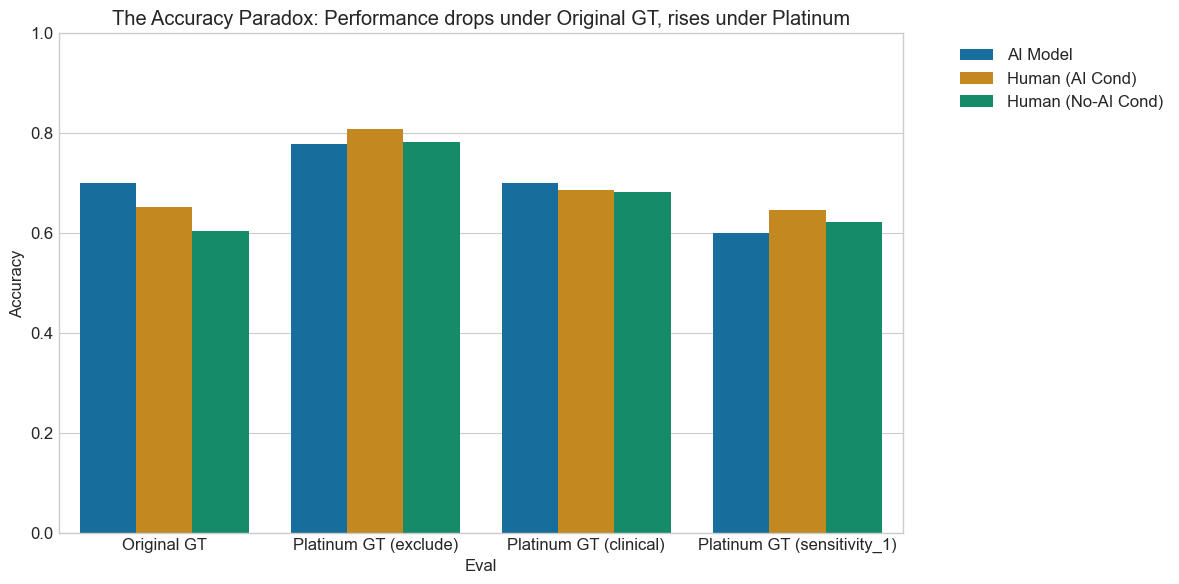

In [5]:
print("--- Accuracy Paradox ---")

plot_data = []

# Original GT (using exclude for clean baseline comparison, since orig has no KL1 anyway, but let's use clinical to keep all images for orig)
df_all = helpers.load_data('clinical', filter_completers=True)
# AI Original
plot_data.append({'Eval': 'Original GT', 'Agent': 'AI Model', 'Acc': accuracy_score(df_all.drop_duplicates('trial_image_name')['gt_original_binary'], df_all.drop_duplicates('trial_image_name')['ai_prediction'])})
# Human AI Cond Orig
plot_data.append({'Eval': 'Original GT', 'Agent': 'Human (AI Cond)', 'Acc': df_all[df_all['condition']=='ai']['human_correct_original'].mean()})
# Human No-AI Cond Orig
plot_data.append({'Eval': 'Original GT', 'Agent': 'Human (No-AI Cond)', 'Acc': df_all[df_all['condition']=='no_ai']['human_correct_original'].mean()})

# Platinum Strategies
for s in strategies:
    df_s = helpers.load_data(s)
    # AI
    plot_data.append({'Eval': f'Platinum GT ({s})', 'Agent': 'AI Model', 'Acc': accuracy_score(df_s.drop_duplicates('trial_image_name')['gt_plat_binary'], df_s.drop_duplicates('trial_image_name')['ai_prediction'])})
    # Human AI
    plot_data.append({'Eval': f'Platinum GT ({s})', 'Agent': 'Human (AI Cond)', 'Acc': df_s[df_s['condition']=='ai']['human_correct_plat'].mean()})
    # Human No-AI
    plot_data.append({'Eval': f'Platinum GT ({s})', 'Agent': 'Human (No-AI Cond)', 'Acc': df_s[df_s['condition']=='no_ai']['human_correct_plat'].mean()})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Eval', y='Acc', hue='Agent', order=['Original GT', 'Platinum GT (exclude)', 'Platinum GT (clinical)', 'Platinum GT (sensitivity_1)'])
plt.title("The Accuracy Paradox: Performance drops under Original GT, rises under Platinum")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Section 5: Wilcoxon and AI Influence Tests

In [6]:
print("--- Wilcoxon Paired Test (Completers) ---")
df_e = helpers.load_data('exclude, filter_completers=True)
df_part = helpers.participant_summary(df_e)
paired = df_part.dropna(subset=['accuracy_ai_condition', 'accuracy_noai_condition'])
from scipy.stats import wilcoxon
w_stat, w_p = wilcoxon(paired['accuracy_ai_condition'], paired['accuracy_noai_condition'])
print(f"Wilcoxon signed-rank test (AI vs Control accuracy, n={len(paired)}): W={w_stat}, p={w_p:.4f}")

print("\n--- AI Influence Test ---")
ai_trials = df_e[df_e['condition'] == 'ai'].dropna(subset=['human_initial_correct_plat', 'human_correct_plat'])
from statsmodels.stats.contingency_tables import mcnemar
tbl = pd.crosstab(ai_trials['human_initial_correct_plat'], ai_trials['human_correct_plat'])
print("Contingency table (Pre-AI vs Post-AI correct):")
print(tbl)
mc_res = mcnemar(tbl, exact=False)
print(f"McNemar test for AI Influence: p={mc_res.pvalue:.4f}")


SyntaxError: EOL while scanning string literal (395422356.py, line 2)